In [1]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
from patsy import dmatrices

# Load dataset

In [13]:
df = pd.read_csv('fremtpl2freq.csv')

## Descriptive statistics and feature visualization

In [14]:
type(df)

pandas.core.frame.DataFrame

In [3]:
df.isna().sum()

IDpol         0
ClaimNb       0
Exposure      0
Area          0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Density       0
Region        0
dtype: int64

In [16]:
df = df.drop(["IDpol"], axis=1)

In [17]:
df = df[df["Exposure"]<=1]

### Identify numerical and categorical features

In [18]:
numerical_features = df.select_dtypes("number").columns.to_list()
categorical_features = df.select_dtypes(exclude="number").columns.to_list()
len(numerical_features)+len(categorical_features)

11

<Axes: >

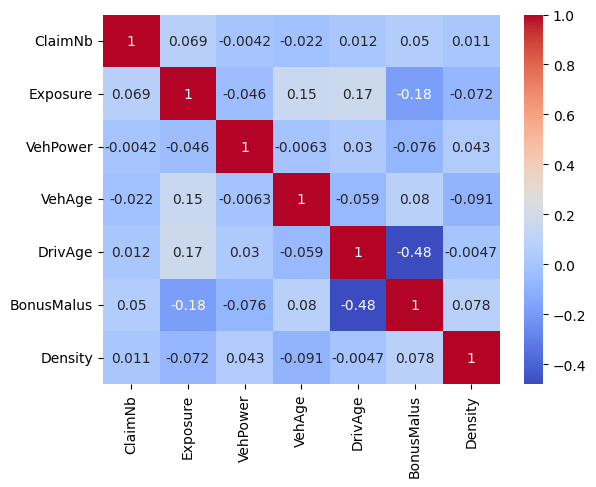

In [19]:
import seaborn as sns
sns.heatmap(df[numerical_features].corr(), cmap="coolwarm", annot=True)

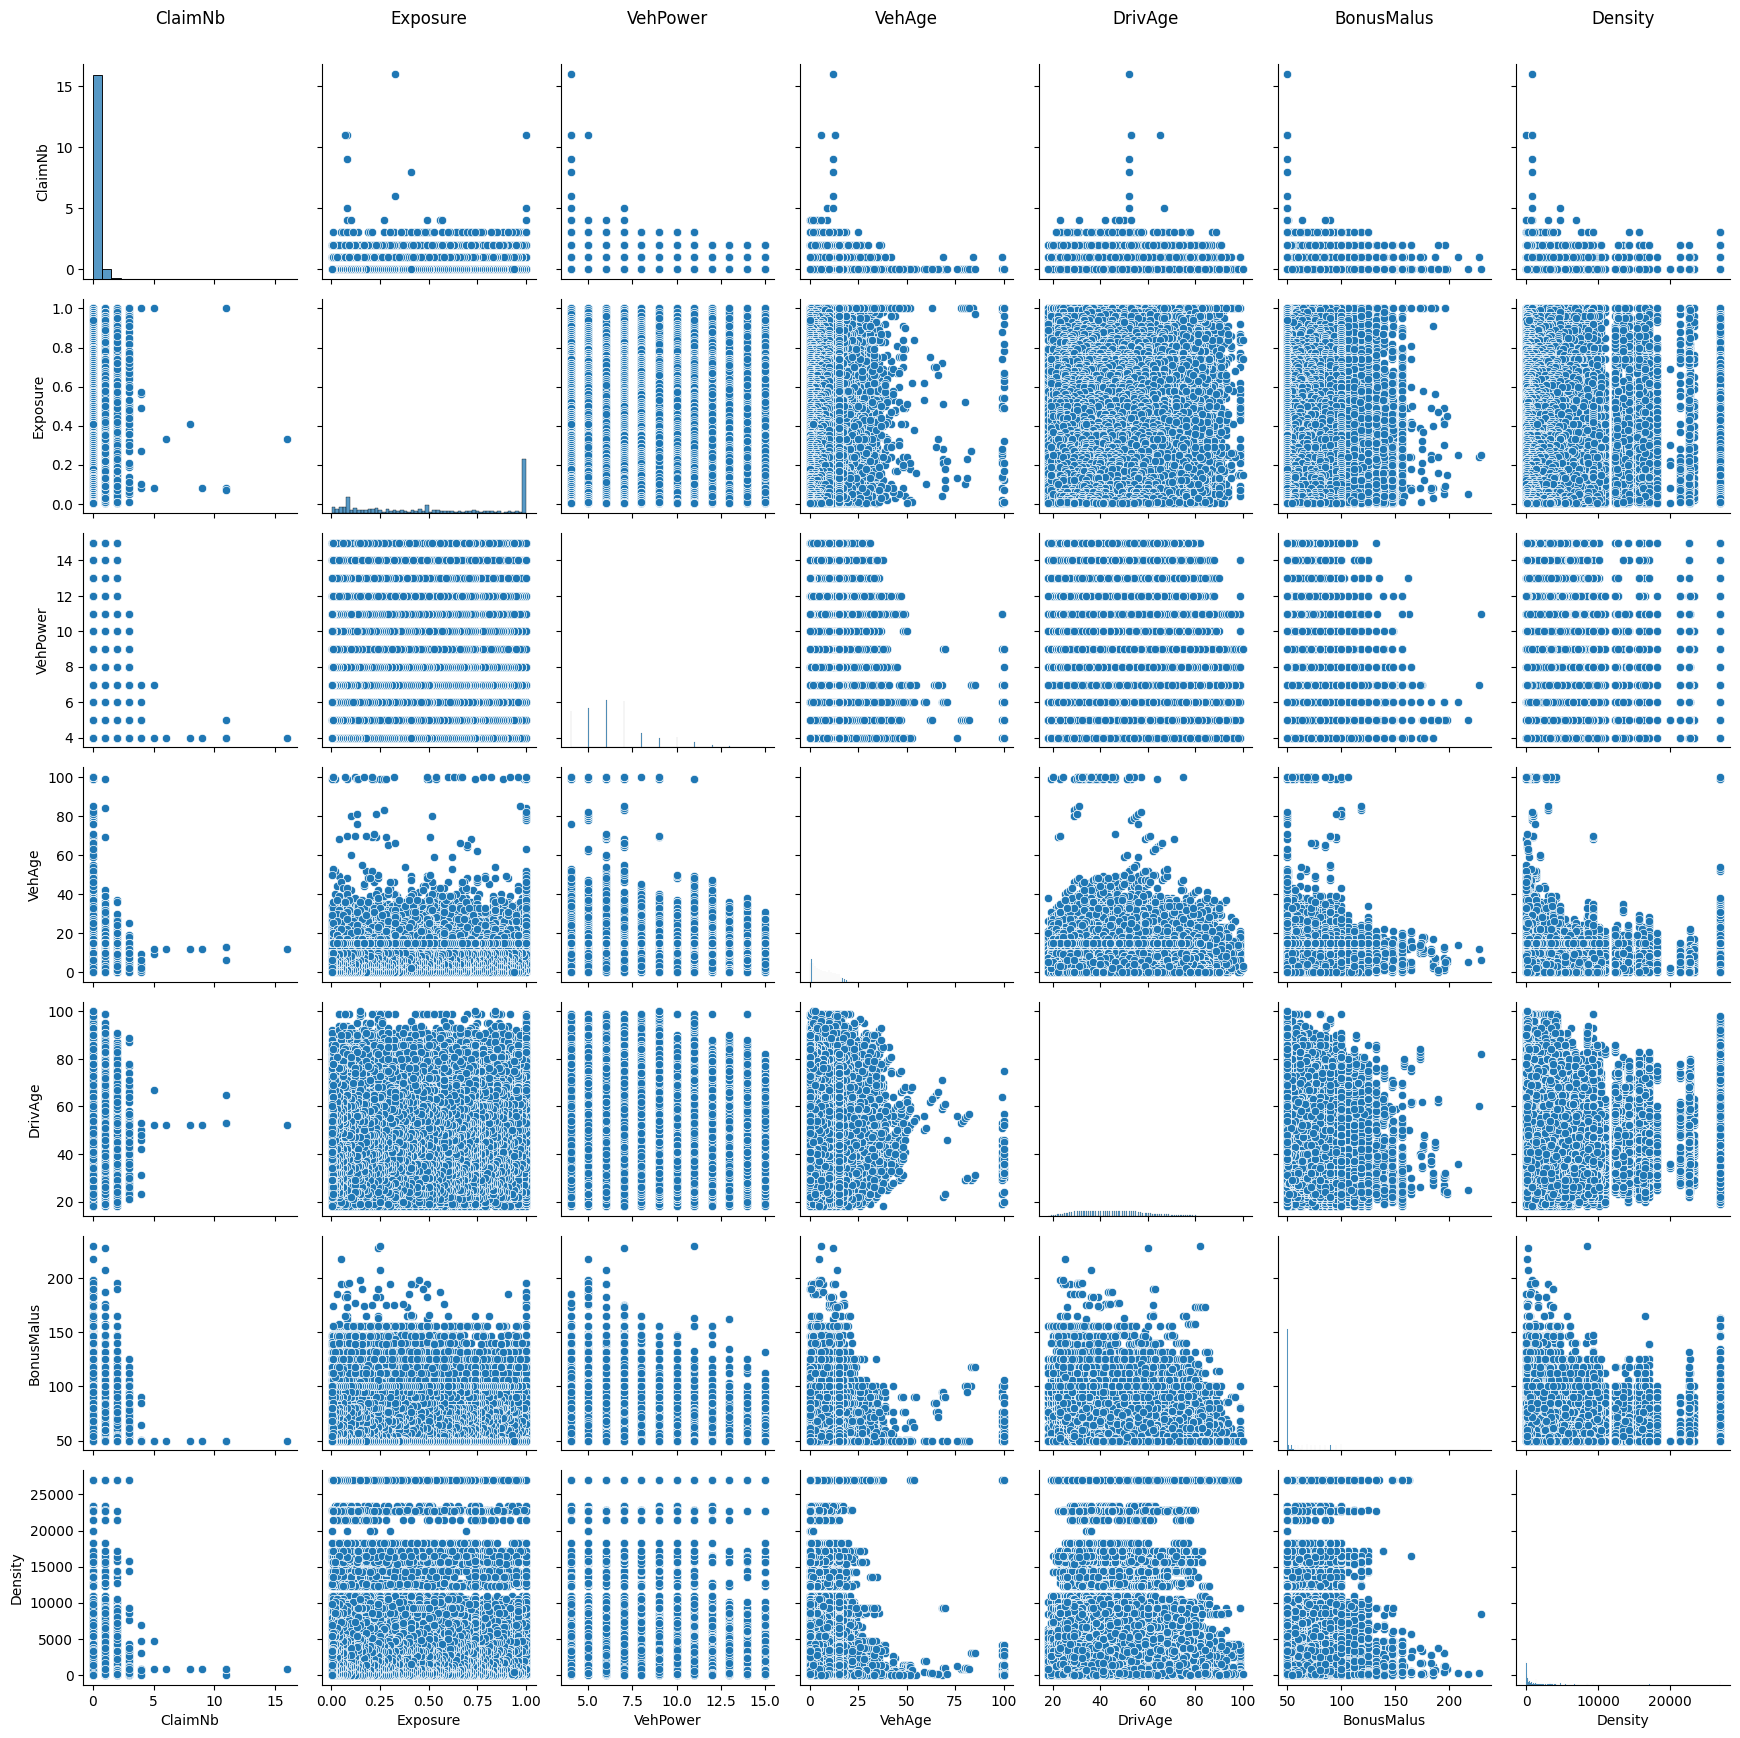

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
g=sns.pairplot(df[numerical_features])
for i, ax in enumerate(g.axes[0]):
    var_name = df[numerical_features].columns[i]
    ax.set_title(var_name, y=1.15)  # y controls how far above

plt.tight_layout()
plt.show()

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


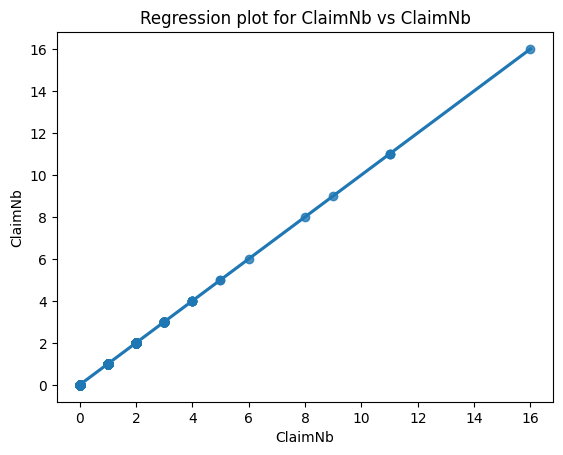

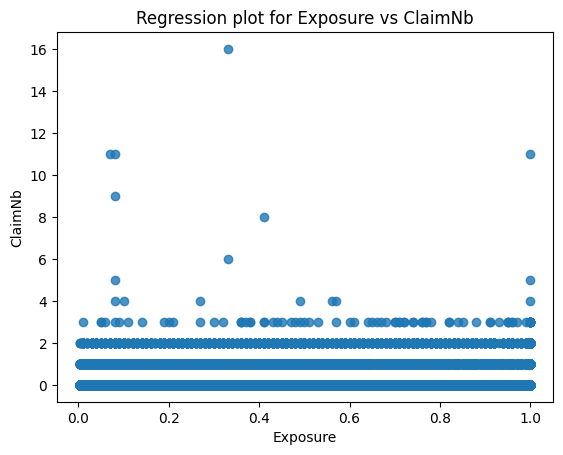

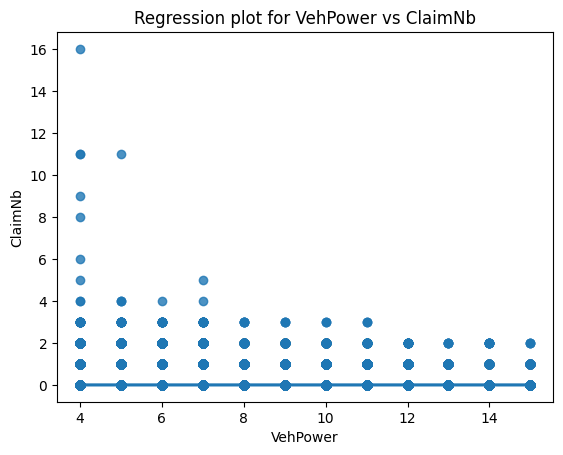

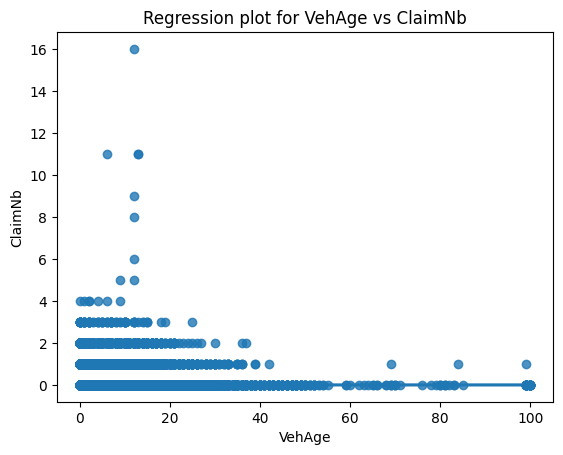

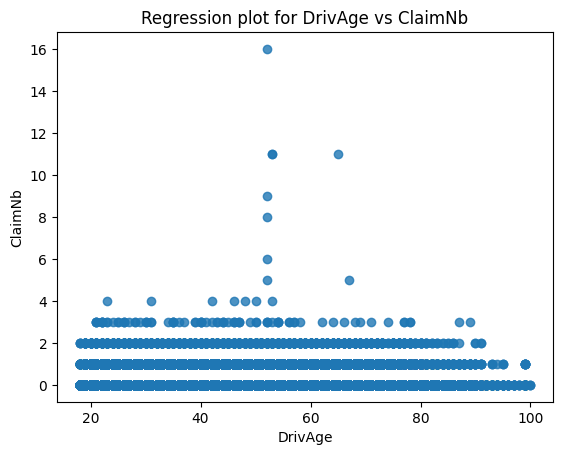

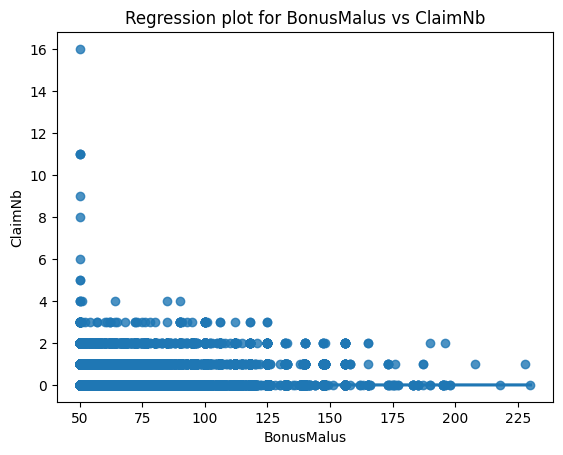

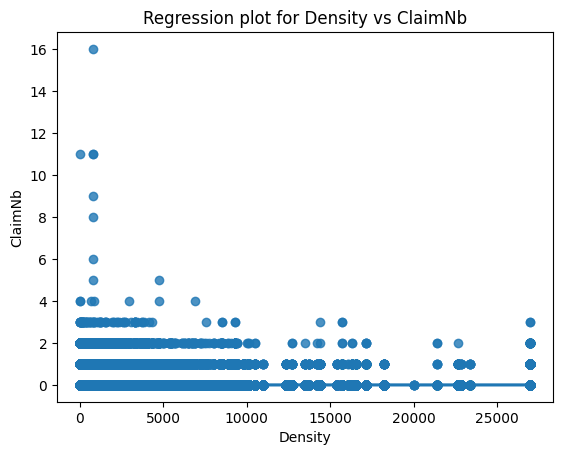

In [26]:
for feature in numerical_features:
    sns.regplot(x=feature, y="ClaimNb", data=df, lowess=True)
    plt.title(f'Regression plot for {feature} vs ClaimNb')
    plt.xlabel(feature)
    plt.ylabel('ClaimNb')
    plt.show()

In [47]:
df_train.select_dtypes("number").columns.to_list()[1:]

['Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']

In [48]:
# Train-test-split
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_features = df_train.select_dtypes("number").columns.to_list()[1:]
df_train[numerical_features] = scaler.fit_transform(df_train[numerical_features])
df_test[numerical_features] = scaler.transform(df_test[numerical_features])

X_train = df_train.drop("ClaimNb", axis=1)
y_train = df_train["ClaimNb"]
X_test = df_test.drop("ClaimNb", axis=1)
y_test = df_test["ClaimNb"]

In [49]:
X_train

,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
385048,1.298232,C,0.264471,-0.537604,1.166841,-0.624341,B1,Regular,-0.361663,R53
98602,-1.422501,D,0.751359,-1.244591,-0.388579,-0.624341,B12,Diesel,-0.317610,R93
221129,-1.037751,D,1.238247,0.876371,-1.873298,2.567358,B2,Regular,0.039371,R24
51235,1.298232,E,0.264471,0.346130,-1.661195,0.780007,B12,Regular,0.495346,R93
292668,-1.175162,A,-0.709305,1.583358,-0.883485,-0.624341,B2,Diesel,-0.443946,R24
...,...,...,...,...,...,...,...,...,...,...
260139,-0.323215,B,-0.222417,1.583358,0.247729,-0.624341,B5,Regular,-0.439895,R24
367062,-1.367537,C,-0.709305,-1.067844,0.813336,-0.624341,B12,Regular,-0.426224,R72
131932,1.298232,E,0.751359,0.169384,-0.742083,-0.624341,B5,Regular,0.495346,R93
672379,0.583696,D,0.751359,-1.067844,1.237542,-0.624341,B12,Regular,-0.090509,R11


In [51]:
# Fit zero-inflated poisson
X_train = sm.add_constant(X_train)

model = sm.ZeroInflatedPoisson(endog=y_train, exog=X_train[numerical_features], offset = np.log(df_train["Exposure"]), exog_infl=X_train[numerical_features])
model.fit().summary()

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:1313: OptimizeWarning: NaN result encountered.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)


         Current function value: nan
         Iterations: 0
         Function evaluations: 1
         Gradient evaluations: 1


/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


KeyboardInterrupt: 